SCT_DS_3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset directly from a reliable public source
url = "https://raw.githubusercontent.com/skathirmani/datasets/master/bank-full.csv"
bank_df = pd.read_csv(url, sep=';')

# 2. Let's see what the data looks like
print("--- Bank Dataset Preview ---")
display(bank_df.head())

# 3. Quick check for missing values
print("\n--- Missing Values Check ---")
print(f"Total missing values: {bank_df.isnull().sum().sum()}")

--- Bank Dataset Preview ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



--- Missing Values Check ---
Total missing values: 0


In [3]:
# 1. Separate features (X) and target variable (y)
# We want to predict the column 'y' (did they purchase?)
X = bank_df.drop(columns=['y'])
y = bank_df['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convert yes/no to 1/0

# 2. Convert all text columns (like job, education) into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

# 3. Split the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Splitting Complete ---")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

--- Data Splitting Complete ---
Training set size: 36168 rows
Testing set size: 9043 rows


In [4]:
# 1. Initialize the Decision Tree model
# We set max_depth=3 so the tree doesn't grow infinitely and become a messy blur
clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Train (fit) the model on our training data
clf.fit(X_train, y_train)

# 3. Predict the outcomes for our test data
y_pred = clf.predict(X_test)

# 4. Check how accurate the model is
accuracy = accuracy_score(y_test, y_pred)
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

--- Model Performance ---
Accuracy Score: 89.59%


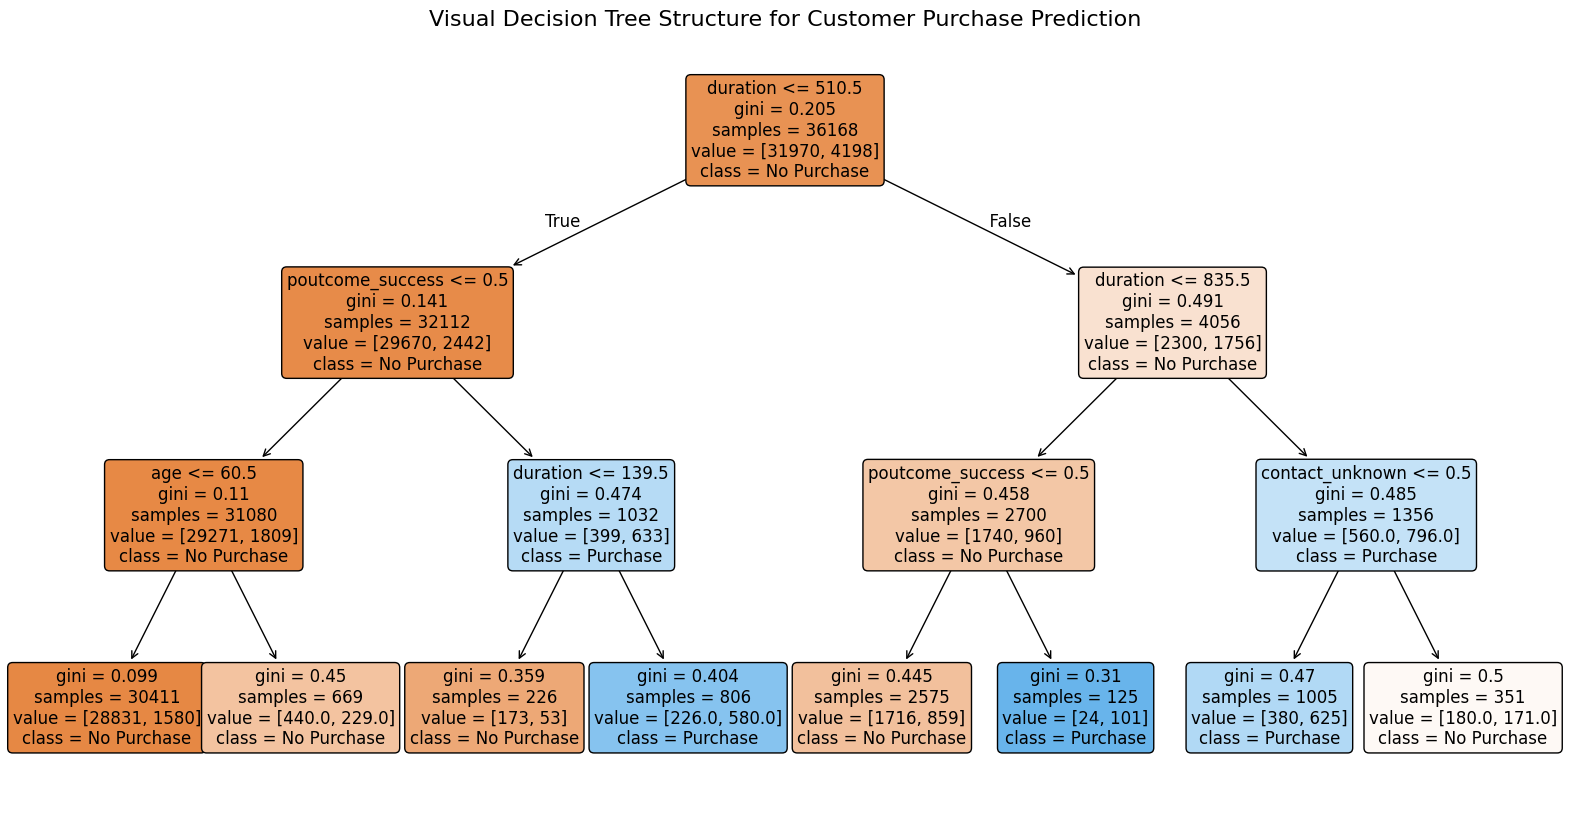

In [5]:
# Set up a large frame so we can see the tree details clearly
plt.figure(figsize=(20, 10))

# Plot the decision tree rules
plot_tree(clf,
          feature_names=X.columns,
          class_names=['No Purchase', 'Purchase'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Visual Decision Tree Structure for Customer Purchase Prediction", fontsize=16)
plt.show()

In [6]:
# Print the classification report and confusion matrix
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

 No Purchase       0.91      0.98      0.94      7952
    Purchase       0.65      0.30      0.41      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043


--- Confusion Matrix ---
[[7777  175]
 [ 766  325]]
